# Preparacao Das Bases

Este notebook le a `Base_Origi`, aplica os ajustes iniciais e define o escopo das bases usadas no restante do projeto.

A regra principal e a idade da filial na data de referencia `2025-12-31`:

- `Base_V1`: filiais com pelo menos 24 meses de operacao;
- `Base_exo`: filiais com menos de 24 meses de operacao.

Ao final, os notebooks seguintes devem usar a `Base_V1` como fonte tratada e elegivel para features, clusterizacao e modelagem. A `Base_exo` fica preservada para analises futuras de filiais jovens.


In [1]:
from pathlib import Path

import pandas as pd
from IPython.display import display

BASE_ORIGI = Path.cwd() / "Base_Origi"
BASE_V1 = Path.cwd() / "Base_V1"
BASE_EXO = Path.cwd() / "Base_exo"

DATA_REFERENCIA_IDADE = pd.Timestamp("2025-12-31")
LIMITE_IDADE_EXO_MESES = 24

ARQUIVOS_ORIGI = {
    "devolucoes": "project-puc_devolucoes.parquet",
    "filiais": "project-puc_filiais.parquet",
    "filiais_dt_abertura": "project-puc_filiais_dt_abertura.parquet",
    "metas": "project-puc_metas.parquet",
    "vendas": "project-puc_vendas.parquet",
}
ARQUIVOS_V1 = {
    "filiais": "filiais_V1.parquet",
    "metas": "metas_V1.parquet",
    "vendas": "vendas_V1.parquet",
    "vendas_diaria": "vendas_diaria_V1.parquet",
}
ARQUIVOS_EXO = {
    "filiais": "filiais_exo.parquet",
    "metas": "metas_exo.parquet",
    "vendas": "vendas_exo.parquet",
    "vendas_diaria": "vendas_diaria_exo.parquet",
}
MAPA_DIA_SEMANA = {
    0: "segunda-feira",
    1: "terca-feira",
    2: "quarta-feira",
    3: "quinta-feira",
    4: "sexta-feira",
    5: "sabado",
    6: "domingo",
}


def normalizar_codigo_filial(serie):
    return serie.astype(str).str.strip()


def ler_arquivos_parquet(base_dir=BASE_ORIGI, arquivos=ARQUIVOS_ORIGI):
    datasets = {}
    faltando = []

    for nome, arquivo in arquivos.items():
        caminho = Path(base_dir) / arquivo
        if not caminho.exists():
            faltando.append(str(caminho))
            continue
        datasets[nome] = pd.read_parquet(caminho)

    if faltando:
        raise FileNotFoundError(
            "Os seguintes arquivos nao foram encontrados:\n- " + "\n- ".join(faltando)
        )

    return datasets


def salvar_arquivos_parquet(datasets, base_dir, arquivos):
    base_dir.mkdir(parents=True, exist_ok=True)
    caminhos = {}

    for nome, df in datasets.items():
        caminho = base_dir / arquivos[nome]
        df.to_parquet(caminho, index=False)
        caminhos[nome] = str(caminho)

    return caminhos


def excluir_filial(df, codigo, coluna="codigo_filial"):
    mascara = df[coluna].astype(str).str.strip() != str(codigo)
    return df.loc[mascara].copy()


def tabela_freq(df, coluna, ordenar_indice=False):
    quantidade = df[coluna].value_counts(dropna=False)

    if ordenar_indice:
        quantidade = quantidade.sort_index()

    percentual = quantidade / quantidade.sum() * 100

    return pd.DataFrame({
        "quantidade": quantidade,
        "percentual": percentual.round(2),
    })


def separar_data_hora(df, coluna):
    df[f"{coluna}_ts"] = pd.to_datetime(df[coluna], errors="coerce")
    df[f"{coluna}_data"] = df[f"{coluna}_ts"].dt.date
    df[f"{coluna}_hora"] = df[f"{coluna}_ts"].dt.time
    return df


def preparar_base_temporal(df, coluna):
    df = separar_data_hora(df, coluna)
    frequencia_hora = tabela_freq(df, f"{coluna}_hora")
    df = df.drop(columns=[coluna, f"{coluna}_hora", f"{coluna}_ts"])
    return df, frequencia_hora


def adicionar_dia_semana(df, coluna_data, coluna_destino="dia_semana"):
    serie_data = pd.to_datetime(df[coluna_data], errors="coerce")
    df[coluna_destino] = serie_data.dt.weekday.map(MAPA_DIA_SEMANA)
    return df


def valores_decimais(df, coluna):
    serie = df[coluna].dropna()
    return serie[serie % 1 != 0].value_counts().sort_index()


def converter_int_se_possivel(df, coluna):
    serie = df[coluna].dropna()
    if ((serie % 1) == 0).all():
        df[coluna] = df[coluna].astype("Int64")
    return df


def exibir_frequencias(df, colunas, ordenar_indice=False):
    for coluna in colunas:
        print(coluna)
        display(tabela_freq(df, coluna, ordenar_indice=ordenar_indice))


def resumo_quantis(df, coluna, quantis=(0.25, 0.5, 0.75, 0.9, 0.95, 0.99)):
    resumo = df[coluna].describe(percentiles=list(quantis))
    return resumo.to_frame(name=coluna)


def top_por_ano(df, ano, metrica, n=10):
    return df.loc[df["ano"] == ano].sort_values(metrica, ascending=False).head(n)


def calcular_idade_meses(data_inicio, data_referencia=DATA_REFERENCIA_IDADE):
    data_inicio = pd.to_datetime(data_inicio, errors="coerce")
    data_referencia = pd.to_datetime(data_referencia)
    meses = (data_referencia.year - data_inicio.dt.year) * 12 + (data_referencia.month - data_inicio.dt.month)
    meses = meses - (data_referencia.day < data_inicio.dt.day).astype("int64")
    return meses.where(data_inicio.notna()).astype("Int64")


def formatar_idade_filial(meses):
    if pd.isna(meses):
        return pd.NA

    meses = int(meses)
    anos = meses // 12
    meses_restantes = meses % 12
    return f"{anos}/{meses_restantes}"


def construir_vendas_diaria_v1(vendas, devol):
    vendas_diarias = (
        vendas.assign(data=pd.to_datetime(vendas["data_emissao_data"], errors="coerce"))
        .groupby(["codigo_filial", "data"], as_index=False)
        .agg(
            cupons_dia=("codigo_documento_saida", "nunique"),
            quantidade_dia=("quantidade", "sum"),
            faturamento_bruto_dia=("faturamento", "sum"),
        )
    )

    devol_diarias = (
        devol.assign(data=pd.to_datetime(devol["data_devolucao_data"], errors="coerce"))
        .groupby(["codigo_filial", "data"], as_index=False)
        .agg(valor_devolucao_dia=("valor_devolucao", "sum"))
    )

    vendas_diaria_v1 = vendas_diarias.merge(
        devol_diarias,
        on=["codigo_filial", "data"],
        how="outer",
    )

    vendas_diaria_v1["cupons_dia"] = vendas_diaria_v1["cupons_dia"].fillna(0).astype("Int64")
    vendas_diaria_v1["quantidade_dia"] = vendas_diaria_v1["quantidade_dia"].fillna(0).astype("Int64")
    vendas_diaria_v1["faturamento_bruto_dia"] = vendas_diaria_v1["faturamento_bruto_dia"].fillna(0)
    vendas_diaria_v1["valor_devolucao_dia"] = vendas_diaria_v1["valor_devolucao_dia"].fillna(0)
    vendas_diaria_v1["faturamento_liquido_dia"] = (
        vendas_diaria_v1["faturamento_bruto_dia"] - vendas_diaria_v1["valor_devolucao_dia"]
    )
    vendas_diaria_v1 = adicionar_dia_semana(vendas_diaria_v1, "data")
    vendas_diaria_v1["data"] = vendas_diaria_v1["data"].dt.date

    return vendas_diaria_v1.sort_values(["codigo_filial", "data"]).reset_index(drop=True)


def filtrar_por_filiais(datasets, codigos_filial, manter=True):
    codigos_filial = set(pd.Series(codigos_filial).astype(str).str.strip())
    filtradas = {}

    for nome, df in datasets.items():
        if "codigo_filial" not in df.columns:
            filtradas[nome] = df.copy()
            continue

        mascara = df["codigo_filial"].astype(str).str.strip().isin(codigos_filial)
        if not manter:
            mascara = ~mascara

        filtradas[nome] = df.loc[mascara].copy()

    return filtradas


def tabela_shapes(*grupos):
    linhas = []
    for grupo, datasets in grupos:
        for base, df in datasets.items():
            linhas.append({
                "grupo": grupo,
                "base": base,
                "linhas": len(df),
                "colunas": df.shape[1],
                "filiais": df["codigo_filial"].nunique() if "codigo_filial" in df.columns else pd.NA,
            })
    return pd.DataFrame(linhas)


def separar_base_exo(datasets, limite_idade_meses=LIMITE_IDADE_EXO_MESES):
    filiais_base = datasets["filiais"].copy()

    if "idade_filial_meses" not in filiais_base.columns:
        raise KeyError("A coluna idade_filial_meses precisa existir em filiais antes da separacao.")

    filiais_base["idade_filial_meses"] = pd.to_numeric(filiais_base["idade_filial_meses"], errors="coerce")
    filiais_exo = filiais_base.loc[filiais_base["idade_filial_meses"] < limite_idade_meses].copy()
    codigos_filial_exo = sorted(filiais_exo["codigo_filial"].astype(str).str.strip().unique())

    bases_exo = filtrar_por_filiais(datasets, codigos_filial_exo, manter=True)
    bases_v1 = filtrar_por_filiais(datasets, codigos_filial_exo, manter=False)

    resumo = pd.DataFrame({
        "indicador": [
            "filiais totais apos preparacao",
            "filiais Base Exo (< 24 meses)",
            "filiais Base V1 (>= 24 meses)",
            "menor idade Base Exo",
            "maior idade Base Exo",
            "menor idade Base V1",
            "maior idade Base V1",
        ],
        "valor": [
            filiais_base["codigo_filial"].nunique(),
            bases_exo["filiais"]["codigo_filial"].nunique(),
            bases_v1["filiais"]["codigo_filial"].nunique(),
            bases_exo["filiais"]["idade_filial_meses"].min(),
            bases_exo["filiais"]["idade_filial_meses"].max(),
            bases_v1["filiais"]["idade_filial_meses"].min(),
            bases_v1["filiais"]["idade_filial_meses"].max(),
        ],
    })

    return bases_v1, bases_exo, resumo, filiais_exo


In [2]:
datasets = ler_arquivos_parquet(BASE_ORIGI, ARQUIVOS_ORIGI)

vendas = datasets["vendas"].copy()
filiais = datasets["filiais"].copy()
filiais_dt_abertura = datasets["filiais_dt_abertura"].copy()
devol = datasets["devolucoes"].copy()
metas = datasets["metas"].copy()

print("Leitura das bases em:", BASE_ORIGI)
print("Base V1 sera salva em:", BASE_V1)
print("Base Exo sera salva em:", BASE_EXO)
print("Nomes da Base_V1:", ARQUIVOS_V1)
print("Nomes da Base_exo:", ARQUIVOS_EXO)

{nome: df.shape for nome, df in datasets.items()}


Leitura das bases em: E:\trabalhos\PROJ3- Panvel\Base_Origi
Bases V1 serao salvas em: E:\trabalhos\PROJ3- Panvel\Base_V1
Nomes da Base_V1: {'filiais': 'filiais_V1.parquet', 'metas': 'metas_V1.parquet', 'vendas': 'vendas_V1.parquet', 'vendas_diaria': 'vendas_diaria_V1.parquet'}


{'devolucoes': (85677, 5),
 'filiais': (124, 10),
 'filiais_dt_abertura': (124, 2),
 'metas': (81268, 5),
 'vendas': (20863735, 6)}

## Remover Filial 1704

A filial `1704` e retirada de todas as bases antes das demais transformacoes. Assim, vendas, devolucoes, metas, cadastro de filiais e datas de abertura seguem o mesmo escopo.


In [3]:
filial_excluir = "1704"


linhas_antes = {
    "vendas": len(vendas),
    "filiais": len(filiais),
    "filiais_dt_abertura": len(filiais_dt_abertura),
    "devolucoes": len(devol),
    "metas": len(metas),
}

vendas = excluir_filial(vendas, filial_excluir)
filiais = excluir_filial(filiais, filial_excluir)
filiais_dt_abertura = excluir_filial(filiais_dt_abertura, filial_excluir)
devol = excluir_filial(devol, filial_excluir)
metas = excluir_filial(metas, filial_excluir)

linhas_depois = {
    "vendas": len(vendas),
    "filiais": len(filiais),
    "filiais_dt_abertura": len(filiais_dt_abertura),
    "devolucoes": len(devol),
    "metas": len(metas),
}

pd.DataFrame({
    "antes": linhas_antes,
    "depois": linhas_depois,
    "linhas_removidas": {
        nome: linhas_antes[nome] - linhas_depois[nome]
        for nome in linhas_antes
    },
})


,antes,depois,linhas_removidas
vendas,20863735,20757175,106560
filiais,124,124,0
filiais_dt_abertura,124,124,0
devolucoes,85677,85182,495
metas,81268,80659,609


## Vendas

Prepara a base detalhada de vendas, separando data e hora, criando o dia da semana e conferindo tipos numericos e categorias.


In [4]:
vendas, horas_vendas = preparar_base_temporal(vendas, "data_emissao")
vendas = adicionar_dia_semana(vendas, "data_emissao_data")

display(vendas.head())
display(horas_vendas)

decimais_quantidade_vendas = valores_decimais(vendas, "quantidade")
decimais_quantidade_vendas

,codigo_documento_saida,codigo_filial,categoria_gerencial,quantidade,faturamento,data_emissao_data,dia_semana
0,67092,1818,N-MED,3.0000,20.39,2025-10-06,segunda-feira
1,877535,1647,N-MED,9.0000,397.24,2025-10-12,domingo
2,447919,1710,N-MED,12.0000,634.07,2025-10-22,quarta-feira
3,253891,1755,N-MED,6.0000,72.18,2025-10-10,sexta-feira
4,502024,1692,MED,3.0000,24.81,2025-10-26,domingo


,quantidade,percentual
data_emissao_hora,,
00:00:00,20757175,100.0


Series([], Name: count, dtype: int64)

In [5]:
vendas = converter_int_se_possivel(vendas, "quantidade")

print("codigo_filial distintos:", vendas["codigo_filial"].nunique())
display(tabela_freq(vendas, "categoria_gerencial"))
display(tabela_freq(vendas, "quantidade", ordenar_indice=True))
display(resumo_quantis(vendas, "faturamento"))


codigo_filial distintos: 124


,quantidade,percentual
categoria_gerencial,,
MED,10428906,50.24
N-MED,10328269,49.76


,quantidade,percentual
quantidade,,
3,9529444,45.91
6,4973937,23.96
9,2523571,12.16
12,1429159,6.89
15,799077,3.85
...,...,...
22320,1,0.0
23460,1,0.0
28764,1,0.0


,faturamento
count,2.075718e+07
mean,2.852413e+02
std,1.121738e+03
min,3.000000e-02
25%,5.651000e+01
50%,1.275200e+02
75%,3.011900e+02
90%,6.058400e+02
95%,9.271000e+02
99%,2.519558e+03


In [6]:
cupons_repetidos = vendas["codigo_documento_saida"].value_counts().loc[lambda serie: serie > 1]

print("Quantidade de cupons repetidos:", cupons_repetidos.shape[0])
display(cupons_repetidos.head(20).to_frame(name="ocorrencias"))

Quantidade de cupons repetidos: 1857539


,ocorrencias
codigo_documento_saida,
2160,38
3171,37
6436,36
2644,36
15477,36
1744,36
3128,36
2818,35
2624,35


## Filiais

Revisa o cadastro das filiais e cria agrupamentos cadastrais usados depois nas features, como o grupo de metragem.


In [7]:
display(filiais.head())

print("codigo_filial distintos:", filiais["codigo_filial"].nunique())

,codigo_filial,faixa_vida,localidade,uf,tipo_estabelecimento,delivery,metragem_area_venda,panvel_clinic,estacionamento,atendimento_24_horas
0,1761,MAIS DE 3 ANOS,APUCARANA,PR,BAIRRO,SIM,503.5618,SIM,SIM,NÃO
1,1740,MAIS DE 3 ANOS,LONDRINA,PR,CENTRO,NÃO,531.0054,SIM,SIM,NÃO
2,1689,MAIS DE 3 ANOS,LONDRINA,PR,BAIRRO,NÃO,521.7424,NÃO,SIM,SIM
3,1611,MAIS DE 3 ANOS,LONDRINA,PR,BAIRRO,NÃO,565.2000,SIM,SIM,NÃO
4,1764,MAIS DE 3 ANOS,LONDRINA,PR,CENTRO,NÃO,572.1708,SIM,SIM,NÃO


codigo_filial distintos: 124


In [8]:
exibir_frequencias(
    filiais,
    [
        "faixa_vida",
        "localidade",
        "tipo_estabelecimento",
        "delivery",
        "panvel_clinic",
        "estacionamento",
        "atendimento_24_horas",
    ],
)


faixa_vida


,quantidade,percentual
faixa_vida,,
MAIS DE 3 ANOS,94,75.81
ENTRE 1-2 ANOS,12,9.68
MENOS DE 1 ANO,11,8.87
ENTRE 2-3 ANOS,7,5.65


localidade


,quantidade,percentual
localidade,,
CURITIBA,53,42.74
LONDRINA,14,11.29
MARINGA,13,10.48
CASCAVEL,4,3.23
FOZ DO IGUACU,3,2.42
PONTA GROSSA,3,2.42
TOLEDO,3,2.42
SAO JOSE DOS PINHAIS,3,2.42
ARAPONGAS,2,1.61


tipo_estabelecimento


...

,quantidade,percentual
panvel_clinic,,
SIM,88,70.97
NÃO,36,29.03


estacionamento


,quantidade,percentual
estacionamento,,
SIM,111,89.52
NÃO,13,10.48


atendimento_24_horas


,quantidade,percentual
atendimento_24_horas,,
NÃO,120,96.77
SIM,4,3.23


In [9]:
grupo = 100
max_valor = int(filiais["metragem_area_venda"].max() // grupo * grupo + grupo)
bins = list(range(0, max_valor + grupo, grupo))
labels = [f"{i:03d} a {i+grupo:03d}" for i in bins[:-1]]

filiais["grupo_metragem"] = pd.cut(
    filiais["metragem_area_venda"],
    bins=bins,
    labels=labels,
    right=False,
    include_lowest=True,
)

area_grupo = tabela_freq(filiais, "grupo_metragem", ordenar_indice=True).query("quantidade > 0")
display(area_grupo)


,quantidade,percentual
grupo_metragem,,
200 a 300,2,1.61
300 a 400,14,11.29
400 a 500,35,28.23
500 a 600,62,50.00
600 a 700,7,5.65
700 a 800,3,2.42
1100 a 1200,1,0.81


## Filiais: Data De Abertura

Une a data de inauguracao ao cadastro das filiais e calcula a idade da filial em meses. A coluna `idade_filial` fica no formato `anos/meses`, por exemplo `3/5`.


In [10]:
filiais_dt_abertura = filiais_dt_abertura.copy()
filiais_dt_abertura["codigo_filial"] = filiais_dt_abertura["codigo_filial"].astype(str).str.strip()
filiais_dt_abertura["data_inauguracao_ts"] = pd.to_datetime(
    filiais_dt_abertura["data_inauguracao"],
    errors="coerce",
)
filiais_dt_abertura["data_inauguracao_data"] = filiais_dt_abertura["data_inauguracao_ts"].dt.date
filiais_dt_abertura["ano_inauguracao"] = filiais_dt_abertura["data_inauguracao_ts"].dt.year
filiais_dt_abertura["mes_inauguracao"] = filiais_dt_abertura["data_inauguracao_ts"].dt.month
filiais_dt_abertura["dia_semana_inauguracao"] = filiais_dt_abertura["data_inauguracao_ts"].dt.weekday.map(MAPA_DIA_SEMANA)
filiais_dt_abertura["idade_filial_meses"] = calcular_idade_meses(filiais_dt_abertura["data_inauguracao_ts"])
filiais_dt_abertura["idade_filial"] = filiais_dt_abertura["idade_filial_meses"].map(formatar_idade_filial)

colunas_idade_filiais = [
    "codigo_filial",
    "idade_filial_meses",
    "idade_filial",
]

colunas_abertura_remover = [
    "data_inauguracao_data",
    "ano_inauguracao",
    "mes_inauguracao",
    "dia_semana_inauguracao",
    "idade_filial_meses",
    "idade_filial",
]

filiais = filiais.copy()
filiais["codigo_filial"] = filiais["codigo_filial"].astype(str).str.strip()
filiais = filiais.drop(columns=[coluna for coluna in colunas_abertura_remover if coluna in filiais.columns])
filiais = filiais.merge(
    filiais_dt_abertura[colunas_idade_filiais],
    on="codigo_filial",
    how="left",
)

display(filiais_dt_abertura.head())
display(filiais[["codigo_filial", "idade_filial_meses", "idade_filial"]].head())

print("Data de referencia para idade:", DATA_REFERENCIA_IDADE.date())
print("Shape filiais_dt_abertura:", filiais_dt_abertura.shape)
print("Shape filiais enriquecida:", filiais.shape)
print("codigo_filial distintos:", filiais_dt_abertura["codigo_filial"].nunique())
print("Data minima:", filiais_dt_abertura["data_inauguracao_ts"].min())
print("Data maxima:", filiais_dt_abertura["data_inauguracao_ts"].max())

display(pd.DataFrame({
    "tipo": filiais_dt_abertura.dtypes.astype(str),
    "nulos": filiais_dt_abertura.isna().sum(),
    "percentual_nulos": (filiais_dt_abertura.isna().mean() * 100).round(2),
}))

display(resumo_quantis(filiais, "idade_filial_meses"))

codigos_filiais = set(filiais["codigo_filial"].astype(str).str.strip())
codigos_abertura = set(filiais_dt_abertura["codigo_filial"].astype(str).str.strip())

print("Codigos somente em filiais:", sorted(codigos_filiais - codigos_abertura))
print("Codigos somente em filiais_dt_abertura:", sorted(codigos_abertura - codigos_filiais))


,codigo_filial,data_inauguracao,data_inauguracao_ts,data_inauguracao_data,ano_inauguracao,mes_inauguracao,dia_semana_inauguracao,idade_filial_meses,idade_filial
0,1761,2022-07-27 03:00:00,2022-07-27 03:00:00,2022-07-27,2022,7,quarta-feira,41,3/5
1,1740,2021-06-30 03:00:00,2021-06-30 03:00:00,2021-06-30,2021,6,quarta-feira,54,4/6
2,1689,2019-11-29 03:00:00,2019-11-29 03:00:00,2019-11-29,2019,11,sexta-feira,73,6/1
3,1611,2016-08-12 03:00:00,2016-08-12 03:00:00,2016-08-12,2016,8,sexta-feira,112,9/4
4,1764,2022-03-24 03:00:00,2022-03-24 03:00:00,2022-03-24,2022,3,quinta-feira,45,3/9


,codigo_filial,idade_filial_meses,idade_filial
0,1761,41,3/5
1,1740,54,4/6
2,1689,73,6/1
3,1611,112,9/4
4,1764,45,3/9


Data de referencia para idade: 2025-12-31
Shape filiais_dt_abertura: (124, 9)
Shape filiais enriquecida: (124, 13)
codigo_filial distintos: 124
Data minima: 2010-12-01 02:00:00
Data maxima: 2025-12-05 03:00:00


,tipo,nulos,percentual_nulos
codigo_filial,object,0,0.0
data_inauguracao,datetime64[ns],0,0.0
data_inauguracao_ts,datetime64[ns],0,0.0
data_inauguracao_data,object,0,0.0
ano_inauguracao,int32,0,0.0
mes_inauguracao,int32,0,0.0
dia_semana_inauguracao,object,0,0.0
idade_filial_meses,Int64,0,0.0
idade_filial,object,0,0.0


,idade_filial_meses
count,124.0
mean,77.669355
std,53.206412
min,0.0
25%,36.25
50%,73.0
75%,120.25
90%,154.1
95%,167.55
99%,180.0


Codigos somente em filiais: []
Codigos somente em filiais_dt_abertura: []


In [11]:
print("Distribuicao por ano de inauguracao")
display(tabela_freq(filiais_dt_abertura, "ano_inauguracao", ordenar_indice=True))

print("Distribuicao por mes de inauguracao")
display(tabela_freq(filiais_dt_abertura, "mes_inauguracao", ordenar_indice=True))

print("Distribuicao por dia da semana de inauguracao")
display(tabela_freq(filiais_dt_abertura, "dia_semana_inauguracao"))


Distribuicao por ano de inauguracao


,quantidade,percentual
ano_inauguracao,,
2010,4,3.23
2011,3,2.42
2012,5,4.03
2013,10,8.06
2014,3,2.42
2015,7,5.65
2016,7,5.65
2017,8,6.45
2018,8,6.45


Distribuicao por mes de inauguracao


,quantidade,percentual
mes_inauguracao,,
1,6,4.84
2,6,4.84
3,6,4.84
4,11,8.87
5,9,7.26
6,12,9.68
7,8,6.45
8,10,8.06
9,12,9.68


Distribuicao por dia da semana de inauguracao


,quantidade,percentual
dia_semana_inauguracao,,
sexta-feira,29,23.39
segunda-feira,28,22.58
terca-feira,21,16.94
quarta-feira,20,16.13
quinta-feira,19,15.32
sabado,6,4.84
domingo,1,0.81


## Devolucoes

Prepara a base de devolucoes para consolidacao diaria. A informacao liquida fica disponivel na `Base_V1`, embora a `Base_V2` use somente faturamento bruto.


In [12]:
devol, horas_devolucao = preparar_base_temporal(devol, "data_devolucao")
display(devol.head())

print("codigo_filial distintos:", devol["codigo_filial"].nunique())
display(tabela_freq(devol, "codigo_filial").head(20))
display(horas_devolucao)

decimais_quantidade_devol = valores_decimais(devol, "quantidade")
decimais_quantidade_devol


,codigo_filial,categoria_gerencial,quantidade,valor_devolucao,data_devolucao_data
0,1521,N-MED,6.0000,124.35,2025-06-18
1,1749,MED,3.0000,93.01,2025-06-21
2,1689,N-MED,3.0000,370.61,2025-06-30
3,1554,N-MED,18.0000,612.02,2025-06-08
4,1650,MED,15.0000,753.78,2025-06-16


codigo_filial distintos:

 124


,quantidade,percentual
codigo_filial,,
1521,1338,1.57
1557,1275,1.50
1614,1232,1.45
1752,1126,1.32
1617,1076,1.26
1554,1074,1.26
1665,1061,1.25
1767,1034,1.21
1725,1006,1.18


,quantidade,percentual
data_devolucao_hora,,
03:00:00,85182,100.0


Series([], Name: count, dtype: int64)

In [13]:
devol = converter_int_se_possivel(devol, "quantidade")

display(tabela_freq(devol, "categoria_gerencial"))
display(tabela_freq(devol, "quantidade", ordenar_indice=True))
display(resumo_quantis(devol, "valor_devolucao"))

print("Soma quantidade:", devol["quantidade"].sum())
print("Soma valor_devolucao:", devol["valor_devolucao"].sum())


,quantidade,percentual
categoria_gerencial,,
MED,43708,51.31
N-MED,41474,48.69


,quantidade,percentual
quantidade,,
3,33895,39.79
6,18002,21.13
9,10157,11.92
12,6556,7.7
15,4244,4.98
...,...,...
8934,1,0.0
9975,1,0.0
10872,1,0.0


,valor_devolucao
count,85182.000000
mean,792.429467
std,5206.613893
min,0.030000
25%,125.330000
50%,282.060000
75%,604.960000
90%,1255.311000
95%,2242.529500
99%,7495.699800


Soma quantidade: 1164759
Soma valor_devolucao: 67500726.88


In [14]:
vendas_v1 = vendas.copy()
vendas_diaria_v1 = construir_vendas_diaria_v1(vendas_v1, devol)

print("Shape da vendas_V1 detalhada:", vendas_v1.shape)
display(vendas_v1.head())

print("Shape da vendas_diaria_V1:", vendas_diaria_v1.shape)
display(vendas_diaria_v1.head())

Shape da vendas_V1 detalhada: (20757175, 7)


,codigo_documento_saida,codigo_filial,categoria_gerencial,quantidade,faturamento,data_emissao_data,dia_semana
0,67092,1818,N-MED,3,20.39,2025-10-06,segunda-feira
1,877535,1647,N-MED,9,397.24,2025-10-12,domingo
2,447919,1710,N-MED,12,634.07,2025-10-22,quarta-feira
3,253891,1755,N-MED,6,72.18,2025-10-10,sexta-feira
4,502024,1692,MED,3,24.81,2025-10-26,domingo


Shape da vendas_diaria_V1: (79370, 8)


,codigo_filial,data,cupons_dia,quantidade_dia,faturamento_bruto_dia,valor_devolucao_dia,faturamento_liquido_dia,dia_semana
0,1500,2024-01-02,240,1617,48449.24,243.71,48205.53,terca-feira
1,1500,2024-01-03,253,1683,53257.89,430.03,52827.86,quarta-feira
2,1500,2024-01-04,232,1776,57909.36,172.72,57736.64,quinta-feira
3,1500,2024-01-05,286,2175,66140.99,332.98,65808.01,sexta-feira
4,1500,2024-01-06,160,1104,31027.62,103.62,30924.00,sabado


## Metas

Prepara a base de metas, extrai o ano da meta e faz checagens anuais por filial.


In [15]:
print("codigo_filial distintos:", metas["codigo_filial"].nunique())

metas, horas_meta_venda = preparar_base_temporal(metas, "data_meta_venda")
display(horas_meta_venda)

metas["ano"] = pd.to_datetime(metas["data_meta_venda_data"], errors="coerce").dt.year
display(metas.head())


codigo_filial distintos: 124


,quantidade,percentual
data_meta_venda_hora,,
03:00:00,80659,100.0


,codigo_filial,meta_n_med,meta_med,valor_meta_venda,data_meta_venda_data,ano
0,1809,4186.62,7850.25,12036.87,2024-01-01,2024
1,1587,20446.99,21265.08,41712.07,2024-01-01,2024
2,1605,26152.34,34783.16,60935.50,2024-01-01,2024
3,1821,0.00,0.00,0.00,2024-01-01,2024
4,1794,7379.94,9758.59,17138.53,2024-01-01,2024


In [16]:
metas_ano_filial = (
    metas.groupby(["ano", "codigo_filial"], as_index=False)[["meta_n_med", "meta_med", "valor_meta_venda"]]
    .sum()
)

metas_ano_filial["maior_metrica"] = metas_ano_filial[["meta_n_med", "meta_med"]].idxmax(axis=1)
metas_ano_filial.head()


,ano,codigo_filial,meta_n_med,meta_med,valor_meta_venda,maior_metrica
0,2024,1500,7696134.37,13225767.68,20921902.05,meta_med
1,2024,1503,10536374.35,20649851.75,31186226.10,meta_med
2,2024,1506,12301039.34,24092132.12,36393171.46,meta_med
3,2024,1509,7666464.62,13756216.68,21422681.30,meta_med
4,2024,1512,6998335.85,12069756.80,19068092.65,meta_med


In [17]:
anos_metas = sorted(metas_ano_filial["ano"].dropna().astype(int).unique())

for metrica in ["meta_n_med", "meta_med"]:
    for ano in anos_metas:
        print(f"Top 10 de {metrica} em {ano}")
        display(top_por_ano(metas_ano_filial, ano, metrica))


Top 10 de meta_n_med em 2024


,ano,codigo_filial,meta_n_med,meta_med,valor_meta_venda,maior_metrica
7,2024,1521,49147823.59,80110621.76,1.292584e+08,meta_med
18,2024,1557,24076352.34,40457245.31,6.453360e+07,meta_med
61,2024,1698,20576251.30,26597495.65,4.717375e+07,meta_med
36,2024,1614,18688357.71,32991596.44,5.167995e+07,meta_med
14,2024,1545,16738059.32,21819793.67,3.855785e+07,meta_med
17,2024,1554,16369181.74,28547934.05,4.491712e+07,meta_med
5,2024,1515,15549996.24,26639922.94,4.218992e+07,meta_med
48,2024,1656,15505396.88,27499418.46,4.300482e+07,meta_med
16,2024,1551,15444474.10,26678030.41,4.212250e+07,meta_med
37,2024,1617,15427810.00,24729336.57,4.015715e+07,meta_med


Top 10 de meta_n_med em 2025


,ano,codigo_filial,meta_n_med,meta_med,valor_meta_venda,maior_metrica
119,2025,1521,52752579.06,95333834.39,1.480864e+08,meta_med
173,2025,1698,26095394.59,34432186.07,6.052758e+07,meta_med
130,2025,1557,24716536.84,43724763.56,6.844130e+07,meta_med
148,2025,1614,21868178.68,39408129.01,6.127631e+07,meta_med
129,2025,1554,18717054.42,33048574.49,5.176563e+07,meta_med
126,2025,1545,18248003.60,25419270.11,4.366727e+07,meta_med
177,2025,1713,17329825.96,21767308.44,3.909713e+07,meta_med
170,2025,1689,17301817.88,26832456.65,4.413427e+07,meta_med
160,2025,1656,16383925.04,30601022.65,4.698495e+07,meta_med
128,2025,1551,15398564.55,28079701.90,4.347827e+07,meta_med


Top 10 de meta_med em 2024


,ano,codigo_filial,meta_n_med,meta_med,valor_meta_venda,maior_metrica
7,2024,1521,49147823.59,80110621.76,1.292584e+08,meta_med
18,2024,1557,24076352.34,40457245.31,6.453360e+07,meta_med
36,2024,1614,18688357.71,32991596.44,5.167995e+07,meta_med
17,2024,1554,16369181.74,28547934.05,4.491712e+07,meta_med
48,2024,1656,15505396.88,27499418.46,4.300482e+07,meta_med
8,2024,1524,14485106.33,27410510.72,4.189562e+07,meta_med
16,2024,1551,15444474.10,26678030.41,4.212250e+07,meta_med
5,2024,1515,15549996.24,26639922.94,4.218992e+07,meta_med
61,2024,1698,20576251.30,26597495.65,4.717375e+07,meta_med
6,2024,1518,13494659.36,24932679.95,3.842734e+07,meta_med


Top 10 de meta_med em 2025


,ano,codigo_filial,meta_n_med,meta_med,valor_meta_venda,maior_metrica
119,2025,1521,52752579.06,95333834.39,1.480864e+08,meta_med
130,2025,1557,24716536.84,43724763.56,6.844130e+07,meta_med
148,2025,1614,21868178.68,39408129.01,6.127631e+07,meta_med
173,2025,1698,26095394.59,34432186.07,6.052758e+07,meta_med
129,2025,1554,18717054.42,33048574.49,5.176563e+07,meta_med
120,2025,1524,15013497.06,31429956.40,4.644345e+07,meta_med
160,2025,1656,16383925.04,30601022.65,4.698495e+07,meta_med
117,2025,1515,14862096.78,29845550.39,4.470765e+07,meta_med
118,2025,1518,14646973.89,28775875.81,4.342285e+07,meta_med
128,2025,1551,15398564.55,28079701.90,4.347827e+07,meta_med


## Separar Escopo E Salvar Bases

Com as bases preparadas, separamos as filiais jovens da base principal. A `Base_V1` fica com as filiais elegiveis para clusterizacao e modelagem; a `Base_exo` guarda as filiais com menos de 24 meses.


In [18]:
datasets_preparados = {
    "vendas": vendas_v1,
    "vendas_diaria": vendas_diaria_v1,
    "filiais": filiais,
    "metas": metas,
}

bases_v1, bases_exo, resumo_separacao, filiais_exo = separar_base_exo(datasets_preparados)

display(resumo_separacao)
display(
    filiais_exo[
        ["codigo_filial", "idade_filial_meses", "idade_filial", "tipo_estabelecimento"]
    ].sort_values("idade_filial_meses")
)

display(tabela_shapes(
    ("base_total_preparada", datasets_preparados),
    ("base_v1_elegivel", bases_v1),
    ("base_exo_menos_24_meses", bases_exo),
))

caminhos_salvos = {
    "base_v1": salvar_arquivos_parquet(bases_v1, BASE_V1, ARQUIVOS_V1),
    "base_exo": salvar_arquivos_parquet(bases_exo, BASE_EXO, ARQUIVOS_EXO),
}

display(pd.DataFrame(caminhos_salvos).rename_axis("base").reset_index())


filiais          E:\trabalhos\PROJ3- Panvel\Base_V1\filiais_V1....
metas            E:\trabalhos\PROJ3- Panvel\Base_V1\metas_V1.pa...
vendas           E:\trabalhos\PROJ3- Panvel\Base_V1\vendas_V1.p...
vendas_diaria    E:\trabalhos\PROJ3- Panvel\Base_V1\vendas_diar...
Name: arquivo_salvo, dtype: object

## Visualizacoes E Insights

Graficos finais para leitura do comportamento de vendas, devolucoes, metas e perfil das filiais. Eles ajudam a validar se a preparacao preservou padroes comerciais importantes antes das etapas de features e clusterizacao.


In [19]:
import matplotlib.pyplot as plt
import numpy as np
from matplotlib.ticker import FuncFormatter, MaxNLocator, PercentFormatter
from IPython.display import Markdown

plt.style.use("seaborn-v0_8-whitegrid")
plt.rcParams.update({
    "figure.facecolor": "white",
    "axes.facecolor": "white",
    "axes.edgecolor": "#D1D5DB",
    "axes.labelcolor": "#374151",
    "axes.titlecolor": "#111827",
    "axes.titlesize": 15,
    "axes.titleweight": "bold",
    "font.size": 10,
    "legend.frameon": False,
    "xtick.color": "#4B5563",
    "ytick.color": "#4B5563",
})

PALETA = {
    "azul": "#2563EB",
    "azul_claro": "#93C5FD",
    "laranja": "#F97316",
    "verde": "#16A34A",
    "roxo": "#7C3AED",
    "vermelho": "#DC2626",
    "cinza": "#6B7280",
    "cinza_claro": "#E5E7EB",
}
CORES_CATEGORIA = {
    "MED": PALETA["azul"],
    "N-MED": PALETA["laranja"],
}

ordem_dias = [
    "segunda-feira",
    "terca-feira",
    "quarta-feira",
    "quinta-feira",
    "sexta-feira",
    "sabado",
    "domingo",
]
rotulos_meses_pt = [
    "Jan", "Fev", "Mar", "Abr", "Mai", "Jun",
    "Jul", "Ago", "Set", "Out", "Nov", "Dez",
]
rotulos_dias_curtos = {
    "segunda-feira": "Seg",
    "terca-feira": "Ter",
    "quarta-feira": "Qua",
    "quinta-feira": "Qui",
    "sexta-feira": "Sex",
    "sabado": "Sab",
    "domingo": "Dom",
}


def formata_moeda(valor):
    if pd.isna(valor):
        return "-"
    valor = float(valor)
    abs_valor = abs(valor)
    if abs_valor >= 1_000_000_000:
        return f"R$ {valor / 1_000_000_000:.1f} bi"
    if abs_valor >= 1_000_000:
        return f"R$ {valor / 1_000_000:.1f} mi"
    if abs_valor >= 1_000:
        return f"R$ {valor / 1_000:.0f} mil"
    return f"R$ {valor:.0f}"


def formata_moeda_axis(valor, _pos):
    return formata_moeda(valor)


def label_mes(valor):
    if pd.isna(valor):
        return "-"
    return pd.Timestamp(valor).strftime("%Y-%m")


def limpar_eixo(ax, grade="y"):
    ax.spines["top"].set_visible(False)
    ax.spines["right"].set_visible(False)
    ax.grid(axis=grade, color=PALETA["cinza_claro"], linewidth=0.8)
    ax.set_axisbelow(True)


def rotular_barras_h(ax, valores, fmt="{:.0f}"):
    limite = max(valores) if len(valores) else 0
    deslocamento = limite * 0.015 if limite else 0.1
    for patch, valor in zip(ax.patches, valores):
        ax.text(
            patch.get_width() + deslocamento,
            patch.get_y() + patch.get_height() / 2,
            fmt.format(valor),
            va="center",
            ha="left",
            fontsize=9,
            color="#374151",
        )


def exibir_insights(titulo, *linhas):
    texto = [f"**Insight - {titulo}**"]
    texto.extend(f"- {linha}" for linha in linhas if linha)
    display(Markdown("\n".join(texto)))


vendas_plot = vendas_v1[[
    "codigo_filial",
    "categoria_gerencial",
    "faturamento",
    "data_emissao_data",
    "dia_semana",
]].copy()
vendas_plot["data_plot"] = pd.to_datetime(vendas_plot["data_emissao_data"], errors="coerce")
vendas_plot["mes"] = vendas_plot["data_plot"].dt.to_period("M").dt.to_timestamp()

devol_plot = devol[["codigo_filial", "valor_devolucao", "data_devolucao_data"]].copy()
devol_plot["data_plot"] = pd.to_datetime(devol_plot["data_devolucao_data"], errors="coerce")
devol_plot["mes"] = devol_plot["data_plot"].dt.to_period("M").dt.to_timestamp()
devol_plot["ano"] = devol_plot["data_plot"].dt.year
devol_plot["mes_num"] = devol_plot["data_plot"].dt.month

metas_plot = metas[["codigo_filial", "valor_meta_venda", "data_meta_venda_data"]].copy()
metas_plot["data_plot"] = pd.to_datetime(metas_plot["data_meta_venda_data"], errors="coerce")
metas_plot["mes"] = metas_plot["data_plot"].dt.to_period("M").dt.to_timestamp()

fontes_mes = [
    serie
    for serie in [vendas_plot["mes"], devol_plot["mes"], metas_plot["mes"]]
    if serie.notna().any()
]
if fontes_mes:
    mes_min = min(serie.min() for serie in fontes_mes)
    mes_max = max(serie.max() for serie in fontes_mes)
    meses_referencia = pd.date_range(mes_min, mes_max, freq="MS")
else:
    meses_referencia = pd.DatetimeIndex([])
rotulos_meses = [mes.strftime("%Y-%m") for mes in meses_referencia]

faturamento_diario_categoria = (
    vendas_plot
    .groupby(["data_plot", "mes", "categoria_gerencial"], as_index=False)["faturamento"]
    .sum()
)

faturamento_diario_total = (
    faturamento_diario_categoria
    .groupby(["data_plot", "mes"], as_index=False)["faturamento"]
    .sum()
)

faturamento_medio_mensal_categoria = (
    faturamento_diario_categoria
    .groupby(["mes", "categoria_gerencial"], as_index=False)["faturamento"]
    .mean()
    .rename(columns={"faturamento": "faturamento_medio_diario"})
)

faturamento_medio_mensal_total = (
    faturamento_diario_total
    .groupby("mes", as_index=False)["faturamento"]
    .mean()
    .rename(columns={"faturamento": "faturamento_medio_diario_total"})
    .set_index("mes")
    .reindex(meses_referencia)
    .rename_axis("mes")
    .reset_index()
)

faturamento_mensal_categoria = (
    faturamento_diario_categoria
    .groupby(["mes", "categoria_gerencial"], as_index=False)["faturamento"]
    .sum()
)

faturamento_mensal_total = (
    faturamento_diario_total
    .groupby("mes", as_index=False)["faturamento"]
    .sum()
    .rename(columns={"faturamento": "faturamento_bruto"})
)

metas_mensal = (
    metas_plot
    .groupby("mes", as_index=False)["valor_meta_venda"]
    .sum()
)

devolucao_mensal = (
    devol_plot
    .groupby("mes", as_index=False)["valor_devolucao"]
    .sum()
)

resultado_mensal = (
    pd.DataFrame({"mes": meses_referencia})
    .merge(faturamento_mensal_total, on="mes", how="left")
    .merge(metas_mensal, on="mes", how="left")
    .merge(devolucao_mensal, on="mes", how="left")
)
resultado_mensal[["faturamento_bruto", "valor_meta_venda", "valor_devolucao"]] = (
    resultado_mensal[["faturamento_bruto", "valor_meta_venda", "valor_devolucao"]].fillna(0)
)
resultado_mensal["faturamento_liquido"] = (
    resultado_mensal["faturamento_bruto"] - resultado_mensal["valor_devolucao"]
)
resultado_mensal["atingimento_meta"] = np.where(
    resultado_mensal["valor_meta_venda"] > 0,
    resultado_mensal["faturamento_bruto"] / resultado_mensal["valor_meta_venda"],
    np.nan,
)
resultado_mensal["taxa_devolucao"] = np.where(
    resultado_mensal["faturamento_bruto"] > 0,
    resultado_mensal["valor_devolucao"] / resultado_mensal["faturamento_bruto"],
    np.nan,
)

mix_mensal = (
    faturamento_mensal_categoria
    .pivot(index="mes", columns="categoria_gerencial", values="faturamento")
    .reindex(meses_referencia)
    .fillna(0)
)
for categoria in ["MED", "N-MED"]:
    if categoria not in mix_mensal.columns:
        mix_mensal[categoria] = 0
mix_mensal = mix_mensal[[col for col in ["MED", "N-MED"] if col in mix_mensal.columns]]
mix_mensal_pct = mix_mensal.div(mix_mensal.sum(axis=1).replace(0, np.nan), axis=0)

heatmap_base = vendas_diaria_v1[["data", "dia_semana", "faturamento_bruto_dia"]].copy()
heatmap_base["data_plot"] = pd.to_datetime(heatmap_base["data"], errors="coerce")
heatmap_base["mes"] = heatmap_base["data_plot"].dt.to_period("M").dt.to_timestamp()

heatmap_faturamento = (
    heatmap_base
    .groupby(["dia_semana", "mes"], as_index=False)["faturamento_bruto_dia"]
    .mean()
    .pivot(index="dia_semana", columns="mes", values="faturamento_bruto_dia")
    .reindex(index=ordem_dias, columns=meses_referencia)
)

faixa_vida_plot = filiais["faixa_vida"].value_counts(dropna=False).sort_values()
localidade_plot = filiais["localidade"].value_counts(dropna=False).head(10).sort_values()

if "grupo_metragem" not in filiais.columns:
    grupo = 100
    max_valor = int(filiais["metragem_area_venda"].max() // grupo * grupo + grupo)
    bins = list(range(0, max_valor + grupo, grupo))
    labels = [f"{i:03d} a {i+grupo:03d}" for i in bins[:-1]]
    filiais["grupo_metragem"] = pd.cut(
        filiais["metragem_area_venda"],
        bins=bins,
        labels=labels,
        right=False,
        include_lowest=True,
    )
area_plot = filiais["grupo_metragem"].value_counts(dropna=False).sort_index()
area_plot = area_plot.loc[area_plot > 0].sort_values()

filiais_dt_plot = filiais_dt_abertura.copy()
filiais_dt_plot["data_inauguracao_ts"] = pd.to_datetime(
    filiais_dt_plot["data_inauguracao"],
    errors="coerce",
)
filiais_dt_plot["ano_inauguracao"] = filiais_dt_plot["data_inauguracao_ts"].dt.year
abertura_ano = filiais_dt_plot["ano_inauguracao"].value_counts().sort_index()
if not abertura_ano.empty:
    abertura_ano = abertura_ano.reindex(
        range(int(abertura_ano.index.min()), int(abertura_ano.index.max()) + 1),
        fill_value=0,
    )
abertura_acumulada = abertura_ano.cumsum()

display(Markdown(
    f"Base visual preparada: {len(rotulos_meses)} meses, "
    f"{vendas_plot['codigo_filial'].nunique()} filiais com vendas e "
    f"{len(filiais)} filiais no cadastro."
))

Base visual preparada: 24 meses, 124 filiais com vendas e 124 filiais no cadastro.

### Faturamento x meta

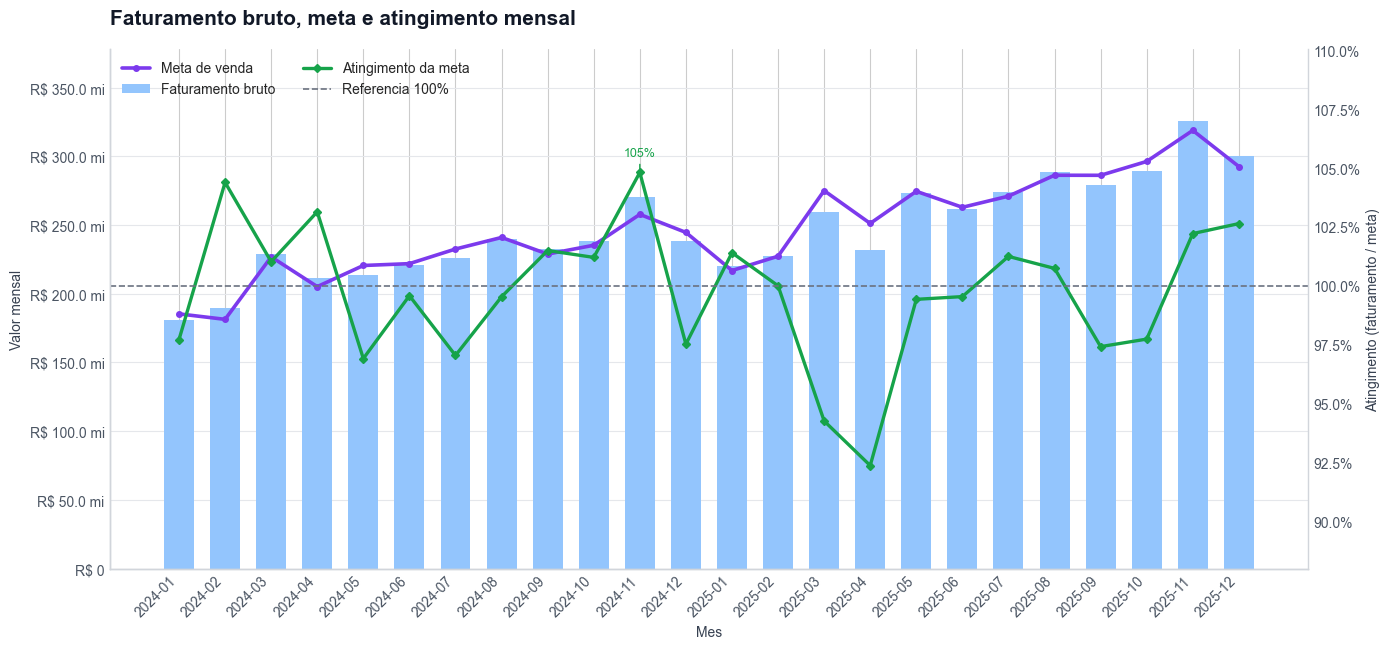

**Insight - faturamento x meta**
- O atingimento mensal é calculado como faturamento bruto do mes dividido pela meta de venda do mesmo mes. A linha verde usa o eixo percentual da direita.
- No periodo completo, o faturamento bruto foi R$ 5.9 bi, frente a uma meta de R$ 5.9 bi. O atingimento consolidado foi 99.7%.
- Melhor atingimento mensal: 2024-11, com 104.8%. Menor atingimento mensal: 2025-04, com 92.4%.
- Maior faturamento bruto mensal: 2025-11, com R$ 325.9 mi.

In [20]:
fig, ax = plt.subplots(figsize=(14, 6.6))
x = np.arange(len(resultado_mensal))

ax.bar(
    x,
    resultado_mensal["faturamento_bruto"],
    color=PALETA["azul_claro"],
    width=0.65,
    label="Faturamento bruto",
)
ax.plot(
    x,
    resultado_mensal["valor_meta_venda"],
    color=PALETA["roxo"],
    linewidth=2.6,
    marker="o",
    markersize=4,
    label="Meta de venda",
)
ax.set_title("Faturamento bruto, meta e atingimento mensal", loc="left", pad=18)
ax.set_ylabel("Valor mensal")
ax.set_xlabel("Mes")
ax.set_xticks(x)
ax.set_xticklabels(rotulos_meses, rotation=45, ha="right")
ax.yaxis.set_major_formatter(FuncFormatter(formata_moeda_axis))
limpar_eixo(ax)

valor_maximo = resultado_mensal[["faturamento_bruto", "valor_meta_venda"]].max().max()
ax.set_ylim(0, valor_maximo * 1.16 if valor_maximo else 1)

ax2 = ax.twinx()
ax2.plot(
    x,
    resultado_mensal["atingimento_meta"],
    color=PALETA["verde"],
    linewidth=2.4,
    marker="D",
    markersize=4,
    label="Atingimento da meta",
)
ax2.axhline(1, color=PALETA["cinza"], linestyle="--", linewidth=1.2, label="Referencia 100%")
ax2.set_ylabel("Atingimento (faturamento / meta)")
ax2.yaxis.set_major_formatter(PercentFormatter(1.0))
ax2.spines["top"].set_visible(False)
ax2.grid(False)

ating_validos = resultado_mensal.dropna(subset=["atingimento_meta"])
if not ating_validos.empty:
    limite_inferior = min(0.88, float(ating_validos["atingimento_meta"].min()) * 0.98)
    limite_superior = max(1.08, float(ating_validos["atingimento_meta"].max()) * 1.05)
    ax2.set_ylim(limite_inferior, limite_superior)

    melhor = ating_validos.loc[ating_validos["atingimento_meta"].idxmax()]
    melhor_idx = int(ating_validos["atingimento_meta"].idxmax())
    ax2.annotate(
        f"{melhor['atingimento_meta']:.0%}",
        xy=(melhor_idx, melhor["atingimento_meta"]),
        xytext=(0, 12),
        textcoords="offset points",
        ha="center",
        color=PALETA["verde"],
        fontsize=9,
        arrowprops={"arrowstyle": "-", "color": PALETA["verde"], "lw": 1},
    )

handles_1, labels_1 = ax.get_legend_handles_labels()
handles_2, labels_2 = ax2.get_legend_handles_labels()
ax.legend(
    handles_1 + handles_2,
    labels_1 + labels_2,
    loc="upper left",
    ncol=2,
)
plt.tight_layout()
plt.show()

if not ating_validos.empty:
    total_faturamento = resultado_mensal["faturamento_bruto"].sum()
    total_meta = resultado_mensal["valor_meta_venda"].sum()
    atingimento_total = total_faturamento / total_meta if total_meta else np.nan
    melhor = ating_validos.loc[ating_validos["atingimento_meta"].idxmax()]
    pior = ating_validos.loc[ating_validos["atingimento_meta"].idxmin()]
    pico = resultado_mensal.loc[resultado_mensal["faturamento_bruto"].idxmax()]
    exibir_insights(
        "faturamento x meta",
        "O atingimento mensal é calculado como faturamento bruto do mes dividido pela meta de venda do mesmo mes. A linha verde usa o eixo percentual da direita.",
        f"No periodo completo, o faturamento bruto foi {formata_moeda(total_faturamento)}, frente a uma meta de {formata_moeda(total_meta)}. O atingimento consolidado foi {atingimento_total:.1%}.",
        f"Melhor atingimento mensal: {label_mes(melhor['mes'])}, com {melhor['atingimento_meta']:.1%}. Menor atingimento mensal: {label_mes(pior['mes'])}, com {pior['atingimento_meta']:.1%}.",
        f"Maior faturamento bruto mensal: {label_mes(pico['mes'])}, com {formata_moeda(pico['faturamento_bruto'])}.",
    )

### Mix de categorias

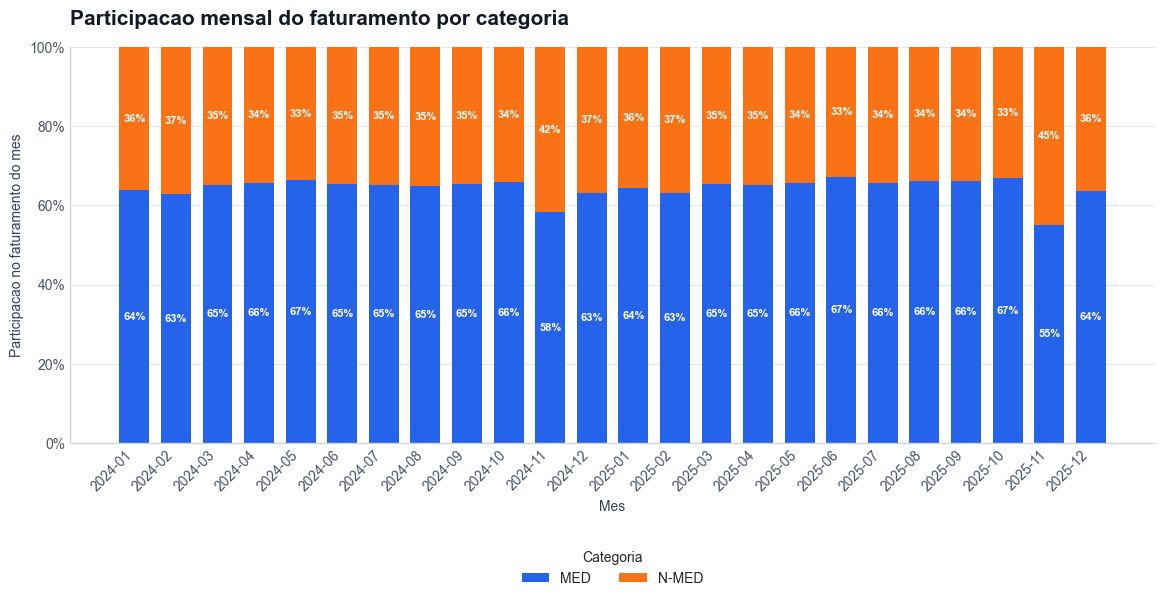

**Insight - mix de categorias**
- No acumulado do periodo, MED soma R$ 3.8 bi (64.3%) e N-MED soma R$ 2.1 bi (35.7%).
- MED supera N-MED em R$ 1.7 bi. Isso equivale a 28.6 pontos percentuais do faturamento total e a 80.3% acima do faturamento de N-MED.
- Maior participacao mensal de MED: 2025-06, com 67.2% do faturamento do mes.

In [21]:
fig, ax = plt.subplots(figsize=(14, 6.6))
x = np.arange(len(mix_mensal_pct))
base = np.zeros(len(mix_mensal_pct))

for categoria in mix_mensal_pct.columns:
    valores = mix_mensal_pct[categoria].fillna(0).to_numpy(dtype=float)
    ax.bar(
        x,
        valores,
        bottom=base,
        width=0.72,
        color=CORES_CATEGORIA.get(categoria, PALETA["cinza"]),
        label=categoria,
    )
    for idx, valor in enumerate(valores):
        if valor >= 0.08:
            ax.text(
                idx,
                base[idx] + valor / 2,
                f"{valor:.0%}",
                ha="center",
                va="center",
                color="white",
                fontsize=8,
                fontweight="bold",
            )
    base += valores

ax.set_title("Participacao mensal do faturamento por categoria", loc="left", pad=16)
ax.set_ylabel("Participacao no faturamento do mes")
ax.set_xlabel("Mes")
ax.set_xticks(x)
ax.set_xticklabels(rotulos_meses, rotation=45, ha="right")
ax.set_ylim(0, 1)
ax.yaxis.set_major_formatter(PercentFormatter(1.0))
limpar_eixo(ax)
ax.legend(
    title="Categoria",
    loc="upper center",
    bbox_to_anchor=(0.5, -0.24),
    ncol=len(mix_mensal_pct.columns),
)
fig.subplots_adjust(bottom=0.30, top=0.90)
plt.show()

faturamento_categoria_total = (
    vendas_plot
    .groupby("categoria_gerencial")["faturamento"]
    .sum()
    .sort_values(ascending=False)
)
participacao_total = faturamento_categoria_total / faturamento_categoria_total.sum()

if len(faturamento_categoria_total) >= 2:
    categoria_lider = faturamento_categoria_total.index[0]
    categoria_segunda = faturamento_categoria_total.index[1]
    valor_lider = faturamento_categoria_total.iloc[0]
    valor_segunda = faturamento_categoria_total.iloc[1]
    pct_lider = participacao_total.iloc[0]
    pct_segunda = participacao_total.iloc[1]
    diferenca_valor = valor_lider - valor_segunda
    diferenca_pontos = (pct_lider - pct_segunda) * 100
    diferenca_relativa = diferenca_valor / valor_segunda if valor_segunda else np.nan
    mes_lider = mix_mensal_pct[categoria_lider].idxmax()
    maior_pct_lider = mix_mensal_pct[categoria_lider].max()

    exibir_insights(
        "mix de categorias",
        f"No acumulado do periodo, {categoria_lider} soma {formata_moeda(valor_lider)} ({pct_lider:.1%}) e {categoria_segunda} soma {formata_moeda(valor_segunda)} ({pct_segunda:.1%}).",
        f"{categoria_lider} supera {categoria_segunda} em {formata_moeda(diferenca_valor)}. Isso equivale a {diferenca_pontos:.1f} pontos percentuais do faturamento total e a {diferenca_relativa:.1%} acima do faturamento de {categoria_segunda}.",
        f"Maior participacao mensal de {categoria_lider}: {label_mes(mes_lider)}, com {maior_pct_lider:.1%} do faturamento do mes.",
    )
elif len(faturamento_categoria_total) == 1:
    categoria_lider = faturamento_categoria_total.index[0]
    valor_lider = faturamento_categoria_total.iloc[0]
    exibir_insights(
        "mix de categorias",
        f"Apenas {categoria_lider} aparece no periodo, somando {formata_moeda(valor_lider)} (100.0%).",
    )

### Devolucoes

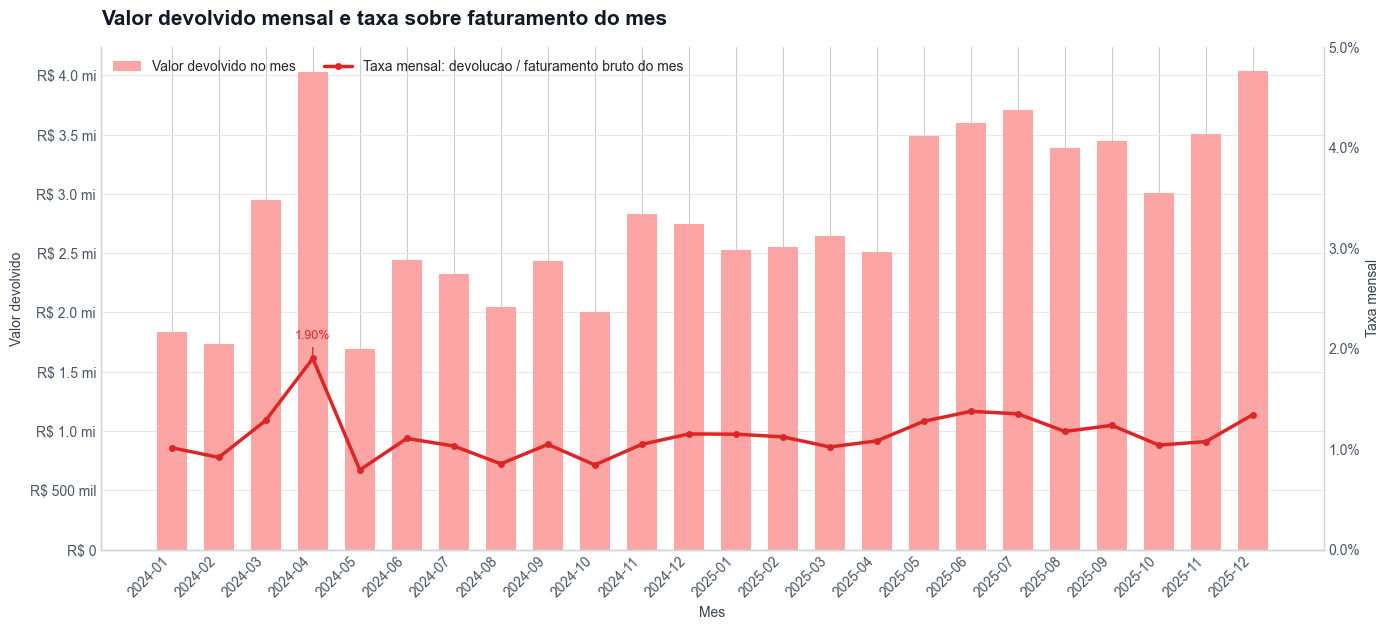

**Insight - devoluções**
- No gráfico, a taxa é mensal: valor devolvido no mes dividido pelo faturamento bruto do mesmo mes.
- No periodo completo, a devolução total foi R$ 67.5 mi, frente a R$ 5.9 bi de faturamento bruto. A taxa consolidada foi 1.14%.
- Maior valor devolvido mensal: 2025-12, com R$ 4.0 mi.
- Maior taxa mensal de devolução: 2024-04, com 1.90%.

In [22]:
fig, ax = plt.subplots(figsize=(14, 6.4))
x = np.arange(len(resultado_mensal))

ax.bar(
    x,
    resultado_mensal["valor_devolucao"],
    color="#FCA5A5",
    width=0.65,
    label="Valor devolvido no mes",
)
ax.set_title("Valor devolvido mensal e taxa sobre faturamento do mes", loc="left", pad=16)
ax.set_ylabel("Valor devolvido")
ax.set_xlabel("Mes")
ax.set_xticks(x)
ax.set_xticklabels(rotulos_meses, rotation=45, ha="right")
ax.yaxis.set_major_formatter(FuncFormatter(formata_moeda_axis))
limpar_eixo(ax)

ax2 = ax.twinx()
ax2.plot(
    x,
    resultado_mensal["taxa_devolucao"],
    color=PALETA["vermelho"],
    linewidth=2.5,
    marker="o",
    markersize=4,
    label="Taxa mensal: devolucao / faturamento bruto do mes",
)
ax2.yaxis.set_major_formatter(PercentFormatter(1.0))
ax2.set_ylabel("Taxa mensal")
ax2.spines["top"].set_visible(False)
ax2.grid(False)

taxas_validas = resultado_mensal.dropna(subset=["taxa_devolucao"])
if not taxas_validas.empty:
    ax2.set_ylim(0, max(0.05, float(taxas_validas["taxa_devolucao"].max()) * 1.25))
    pior_taxa = taxas_validas.loc[taxas_validas["taxa_devolucao"].idxmax()]
    pior_idx = int(taxas_validas["taxa_devolucao"].idxmax())
    ax2.annotate(
        f"{pior_taxa['taxa_devolucao']:.2%}",
        xy=(pior_idx, pior_taxa["taxa_devolucao"]),
        xytext=(0, 14),
        textcoords="offset points",
        ha="center",
        color=PALETA["vermelho"],
        fontsize=9,
        arrowprops={"arrowstyle": "-", "color": PALETA["vermelho"], "lw": 1},
    )

handles_1, labels_1 = ax.get_legend_handles_labels()
handles_2, labels_2 = ax2.get_legend_handles_labels()
ax.legend(handles_1 + handles_2, labels_1 + labels_2, loc="upper left", ncol=2)
plt.tight_layout()
plt.show()

if not taxas_validas.empty:
    total_devolucao = resultado_mensal["valor_devolucao"].sum()
    total_faturamento = resultado_mensal["faturamento_bruto"].sum()
    taxa_total = total_devolucao / total_faturamento if total_faturamento else np.nan
    pior_valor = resultado_mensal.loc[resultado_mensal["valor_devolucao"].idxmax()]
    pior_taxa = taxas_validas.loc[taxas_validas["taxa_devolucao"].idxmax()]
    exibir_insights(
        "devoluções",
        "No gráfico, a taxa é mensal: valor devolvido no mes dividido pelo faturamento bruto do mesmo mes.",
        f"No periodo completo, a devolução total foi {formata_moeda(total_devolucao)}, frente a {formata_moeda(total_faturamento)} de faturamento bruto. A taxa consolidada foi {taxa_total:.2%}.",
        f"Maior valor devolvido mensal: {label_mes(pior_valor['mes'])}, com {formata_moeda(pior_valor['valor_devolucao'])}.",
        f"Maior taxa mensal de devolução: {label_mes(pior_taxa['mes'])}, com {pior_taxa['taxa_devolucao']:.2%}.",
    )

### Sazonalidade semanal

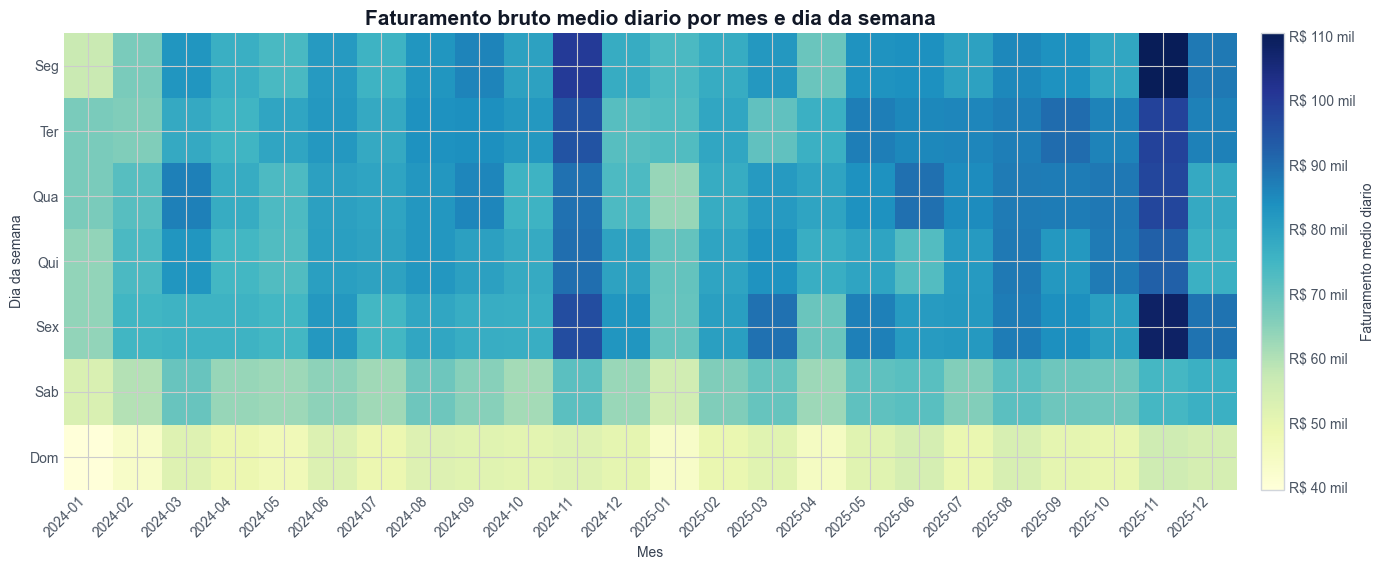

**Insight - sazonalidade semanal**
- Na media diaria, Sexta-feira apresenta o maior faturamento, com R$ 81 mil.
- Domingo apresenta o menor faturamento medio diario, com R$ 50 mil. A diferença entre os dois dias é de R$ 31 mil (61.9% acima do menor dia).
- O heatmap separa a tendencia mensal do comportamento semanal, facilitando a leitura operacional.

In [23]:
fig, ax = plt.subplots(figsize=(14, 5.8))
matriz_heatmap = heatmap_faturamento.to_numpy(dtype=float)
im = ax.imshow(matriz_heatmap, aspect="auto", cmap="YlGnBu")

ax.set_title("Faturamento bruto medio diario por mes e dia da semana")
ax.set_xlabel("Mes")
ax.set_ylabel("Dia da semana")
ax.set_xticks(range(len(rotulos_meses)))
ax.set_xticklabels(rotulos_meses, rotation=45, ha="right")
ax.set_yticks(range(len(heatmap_faturamento.index)))
ax.set_yticklabels([rotulos_dias_curtos.get(dia, dia) for dia in heatmap_faturamento.index])

cbar = plt.colorbar(im, ax=ax, fraction=0.035, pad=0.02)
cbar.ax.yaxis.set_major_formatter(FuncFormatter(formata_moeda_axis))
cbar.set_label("Faturamento medio diario")

for spine in ax.spines.values():
    spine.set_visible(False)
ax.tick_params(length=0)
plt.tight_layout()
plt.show()

media_por_dia = (
    heatmap_base
    .groupby("dia_semana")["faturamento_bruto_dia"]
    .mean()
    .reindex(ordem_dias)
)
if media_por_dia.notna().any():
    melhor_dia = media_por_dia.idxmax()
    menor_dia = media_por_dia.idxmin()
    melhor_dia_texto = str(melhor_dia).capitalize()
    menor_dia_texto = str(menor_dia).capitalize()
    diferenca_dias = media_por_dia.max() - media_por_dia.min()
    diferenca_relativa = diferenca_dias / media_por_dia.min() if media_por_dia.min() else np.nan
    exibir_insights(
        "sazonalidade semanal",
        f"Na media diaria, {melhor_dia_texto} apresenta o maior faturamento, com {formata_moeda(media_por_dia.max())}.",
        f"{menor_dia_texto} apresenta o menor faturamento medio diario, com {formata_moeda(media_por_dia.min())}. A diferença entre os dois dias é de {formata_moeda(diferenca_dias)} ({diferenca_relativa:.1%} acima do menor dia).",
        "O heatmap separa a tendencia mensal do comportamento semanal, facilitando a leitura operacional.",
    )

### Perfil das filiais

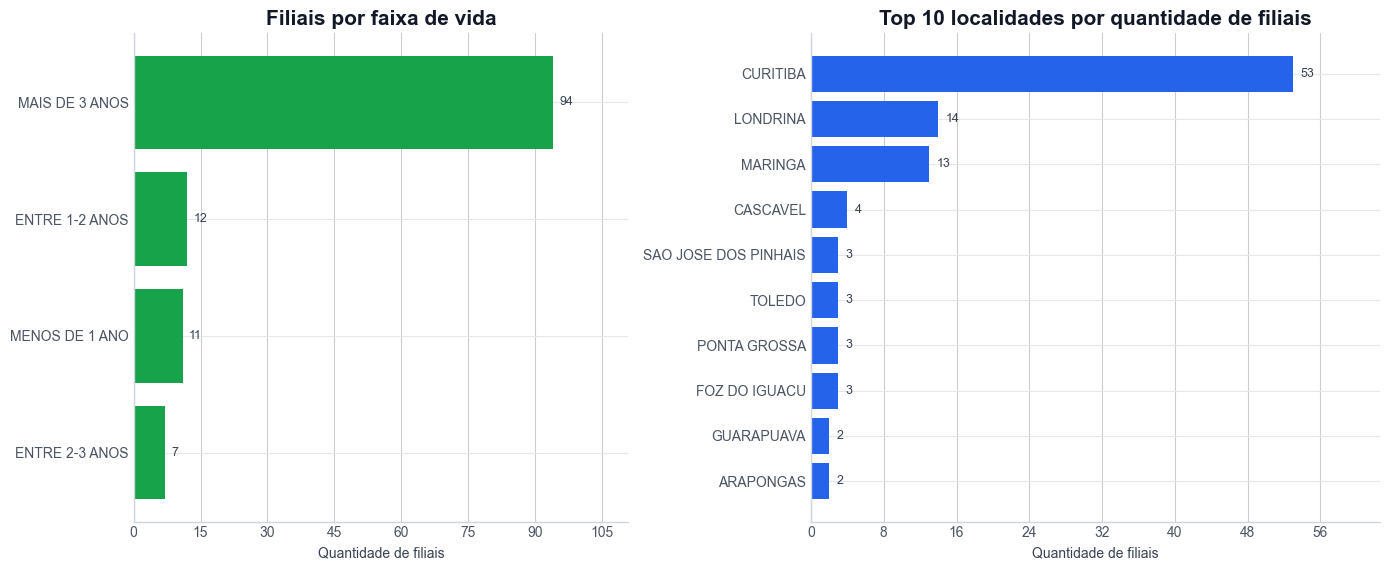

**Insight - perfil das filiais**
- A faixa de vida mais comum é MAIS DE 3 ANOS, com 94 filiais (75.8% da base).
- A maior concentração geográfica esta em CURITIBA, com 53 filiais (42.7% da base).
- Comparações de desempenho entre filiais devem considerar essa concentração por idade e localidade.

In [24]:
fig, axes = plt.subplots(1, 2, figsize=(14, 5.8), gridspec_kw={"width_ratios": [1, 1.15]})

axes[0].barh(
    faixa_vida_plot.index.astype(str),
    faixa_vida_plot.values,
    color=PALETA["verde"],
)
axes[0].set_title("Filiais por faixa de vida")
axes[0].set_xlabel("Quantidade de filiais")
axes[0].xaxis.set_major_locator(MaxNLocator(integer=True))
limpar_eixo(axes[0])
axes[0].set_xlim(0, faixa_vida_plot.max() * 1.18)
rotular_barras_h(axes[0], faixa_vida_plot.values)

axes[1].barh(
    localidade_plot.index.astype(str),
    localidade_plot.values,
    color=PALETA["azul"],
)
axes[1].set_title("Top 10 localidades por quantidade de filiais")
axes[1].set_xlabel("Quantidade de filiais")
axes[1].xaxis.set_major_locator(MaxNLocator(integer=True))
limpar_eixo(axes[1])
axes[1].set_xlim(0, localidade_plot.max() * 1.18)
rotular_barras_h(axes[1], localidade_plot.values)

plt.tight_layout()
plt.show()

faixa_freq = filiais["faixa_vida"].value_counts(dropna=False)
local_freq = filiais["localidade"].value_counts(dropna=False)
faixa_top = faixa_freq.idxmax()
faixa_qtd = faixa_freq.max()
faixa_pct = faixa_qtd / len(filiais)
local_top = local_freq.idxmax()
local_qtd = local_freq.max()
local_pct = local_qtd / len(filiais)
exibir_insights(
    "perfil das filiais",
    f"A faixa de vida mais comum é {faixa_top}, com {faixa_qtd} filiais ({faixa_pct:.1%} da base).",
    f"A maior concentração geográfica esta em {local_top}, com {local_qtd} filiais ({local_pct:.1%} da base).",
    "Comparações de desempenho entre filiais devem considerar essa concentração por idade e localidade.",
)

### Metragem das filiais

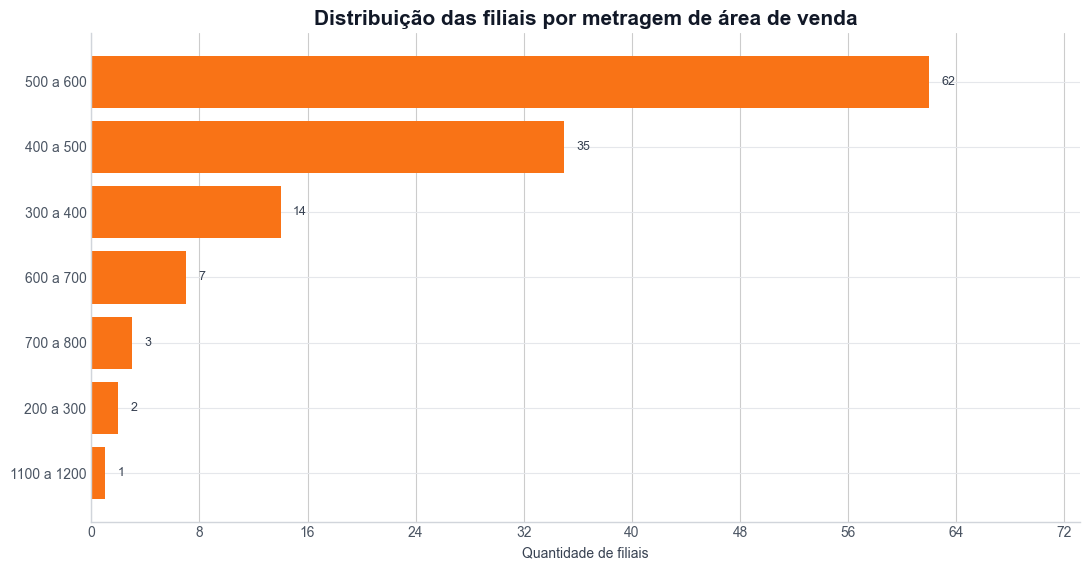

**Insight - metragem**
- A faixa de metragem mais frequente e 500 a 600, com 62 filiais (50.0% da base).
- Essa concentração ajuda a separar o efeito do tamanho fisico da loja do efeito operacional nas proximas analises.

In [25]:
fig, ax = plt.subplots(figsize=(11, 5.8))
ax.barh(
    area_plot.index.astype(str),
    area_plot.values,
    color=PALETA["laranja"],
)
ax.set_title("Distribuição das filiais por metragem de área de venda")
ax.set_xlabel("Quantidade de filiais")
ax.xaxis.set_major_locator(MaxNLocator(integer=True))
limpar_eixo(ax)
ax.set_xlim(0, area_plot.max() * 1.18)
rotular_barras_h(ax, area_plot.values)
plt.tight_layout()
plt.show()

area_top = area_plot.idxmax()
area_qtd = area_plot.max()
area_pct = area_qtd / len(filiais)
exibir_insights(
    "metragem",
    f"A faixa de metragem mais frequente e {area_top}, com {area_qtd} filiais ({area_pct:.1%} da base).",
    "Essa concentração ajuda a separar o efeito do tamanho fisico da loja do efeito operacional nas proximas analises.",
)

### Inauguracoes

C:\Users\celso\AppData\Local\Temp\ipykernel_13228\3409503467.py:66: UserWarning: This figure includes Axes that are not compatible with tight_layout, so results might be incorrect.
  plt.tight_layout()


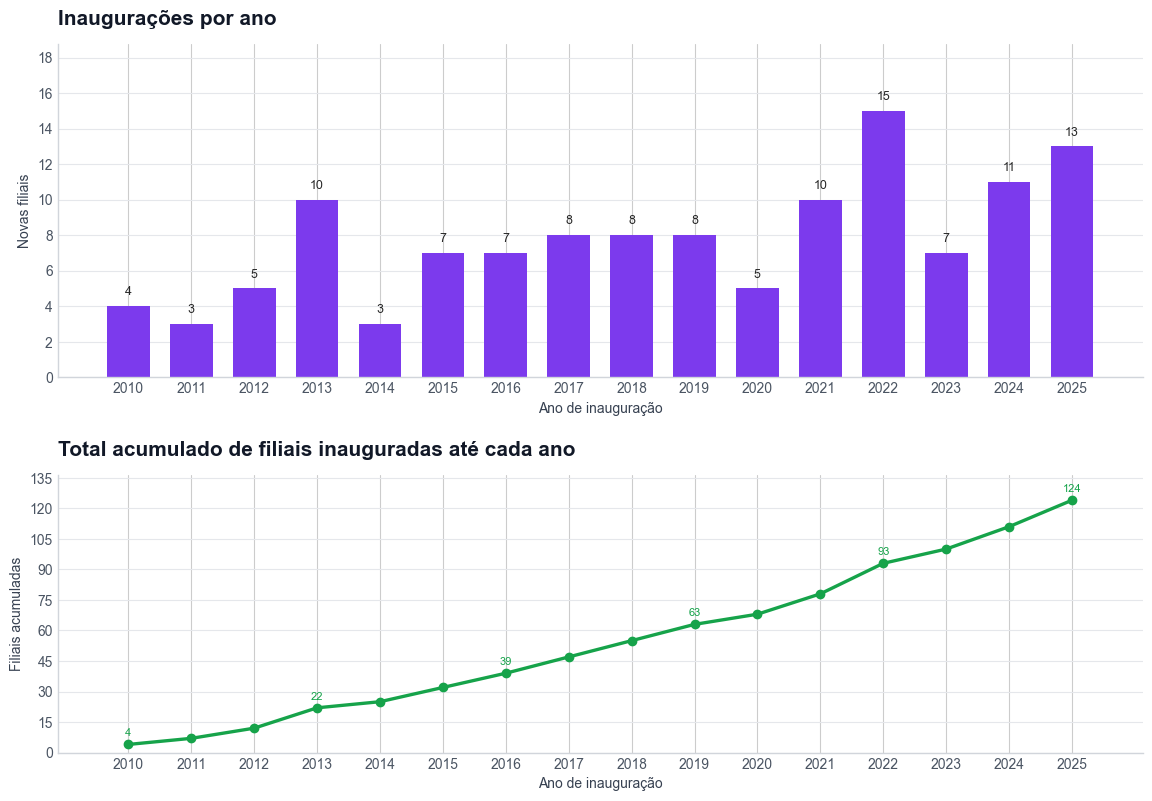

**Insight - inaugurações**
- O acumulado é uma soma progressiva. Em 2010, havia 4 filiais. Em 2011, o total acumulado passa para 7.
- Ao fim de 2025, a base acumula 124 filiais inauguradas.
- O ano com mais inaugurações foi 2022, com 15 novas filiais.
- De 2022 em diante, foram inauguradas 46 filiais.

In [26]:
fig, (ax_ano, ax_acum) = plt.subplots(
    2,
    1,
    figsize=(14, 9.2),
    sharex=True,
    gridspec_kw={"height_ratios": [1.2, 1], "hspace": 0.32},
)
anos = abertura_ano.index.astype(int)
x = np.arange(len(anos))

ax_ano.bar(
    x,
    abertura_ano.values,
    color=PALETA["roxo"],
    width=0.68,
)
ax_ano.set_title("Inaugurações por ano", loc="left", pad=14)
ax_ano.set_ylabel("Novas filiais")
ax_ano.set_xlabel("Ano de inauguração")
ax_ano.set_xticks(x)
ax_ano.set_xticklabels(anos)
ax_ano.tick_params(axis="x", labelbottom=True)
ax_ano.yaxis.set_major_locator(MaxNLocator(integer=True))
limpar_eixo(ax_ano)
ax_ano.set_ylim(0, max(abertura_ano.max() * 1.25, 1))

for idx, valor in enumerate(abertura_ano.values):
    if valor > 0:
        ax_ano.text(
            idx,
            valor + abertura_ano.max() * 0.03,
            str(int(valor)),
            ha="center",
            va="bottom",
            fontsize=9,
        )

ax_acum.plot(
    x,
    abertura_acumulada.values,
    color=PALETA["verde"],
    marker="o",
    linewidth=2.4,
)
ax_acum.set_title("Total acumulado de filiais inauguradas até cada ano", loc="left", pad=14)
ax_acum.set_ylabel("Filiais acumuladas")
ax_acum.set_xlabel("Ano de inauguração")
ax_acum.set_xticks(x)
ax_acum.set_xticklabels(anos)
ax_acum.yaxis.set_major_locator(MaxNLocator(integer=True))
limpar_eixo(ax_acum)
ax_acum.set_ylim(0, max(abertura_acumulada.max() * 1.10, 1))

for idx, valor in enumerate(abertura_acumulada.values):
    if idx in {0, len(abertura_acumulada) - 1} or idx % 3 == 0:
        ax_acum.text(
            idx,
            valor + abertura_acumulada.max() * 0.025,
            str(int(valor)),
            ha="center",
            va="bottom",
            fontsize=8,
            color=PALETA["verde"],
        )

plt.tight_layout()
plt.show()

if not abertura_ano.empty:
    ano_pico = int(abertura_ano.idxmax())
    qtd_pico = int(abertura_ano.max())
    recentes = int(abertura_ano.loc[abertura_ano.index >= 2022].sum())
    total_final = int(abertura_acumulada.iloc[-1])
    primeiro_ano = int(abertura_ano.index.min())
    segundo_ano = int(abertura_ano.index[1]) if len(abertura_ano.index) > 1 else primeiro_ano
    acumulado_primeiro = int(abertura_acumulada.iloc[0])
    acumulado_segundo = int(abertura_acumulada.iloc[1]) if len(abertura_acumulada) > 1 else acumulado_primeiro
    exibir_insights(
        "inaugurações",
        f"O acumulado é uma soma progressiva. Em {primeiro_ano}, havia {acumulado_primeiro} filiais. Em {segundo_ano}, o total acumulado passa para {acumulado_segundo}.",
        f"Ao fim de {int(abertura_ano.index.max())}, a base acumula {total_final} filiais inauguradas.",
        f"O ano com mais inaugurações foi {ano_pico}, com {qtd_pico} novas filiais.",
        f"De 2022 em diante, foram inauguradas {recentes} filiais.",
    )